# Convex Rank Selection for Parameter-Efficient Fine-Tuning of Language Models

**Authors:** Saurabh Sahebrao Gujar & Aditi Karanjkar

---

### Overview
This notebook presents a framework for optimizing the rank of **Low-Rank Adaptation (LoRA)** modules using **Truncated Singular Value Thresholding (SVT)**. 

By applying **nuclear norm penalization** to gradient matrices, we automatically select the optimal rank per layer. This adaptive approach balances the **bias-variance tradeoff** efficiently - allocating more parameters to layers that capture complex task features while regularizing simpler transformations to prevent overfitting.

### Discussion: Bias-Variance Tradeoff in Rank Selection

A central motivation for adaptive rank selection is the inherent bias-variance tradeoff that governs all low-rank approximations in PEFT.

**High Rank (small λ penalty):** Assigning a large rank to every layer gives the model a larger parameter space. This reduces bias  -  the model has sufficient capacity to fit complex, task-specific patterns. However, it also increases variance by making the model prone to overfitting, particularly on small datasets such as MRPC (3,668 training examples). It also wastes parameters on layers that do not require high-frequency feature adaptation.

**Low Rank (large λ penalty):** A small rank heavily constrains the update subspace, acting as a regularizer. This reduces variance by preventing the model from memorizing noise, but increases bias: the adapter may lack the capacity to represent the full task-relevant transformation.

**Our Approach  -  Layer-Adaptive SVT:** Rather than applying a uniform rank across all layers, our Singular Value Thresholding (SVT) algorithm adaptively assigns rank layer-by-layer based on the gradient singular value spectrum. Layers with a rapidly decaying spectrum (small dominant singular values) receive low rank, as they do not require high-dimensional updates. Layers with a slowly decaying spectrum receive higher rank, reflecting their greater task relevance. This mirrors the classical bias-variance tradeoff in a structured way: the regularization parameter λ controls the global budget, while the singular value spectrum allocates it where the model signal is strongest.

## Install

In [1]:
!pip install -q transformers datasets peft evaluate accelerate scikit-learn scipy "torchao>=0.16.0"
print('Packages installed')



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 27.9 MB/s eta 0:00:00
Packages installed


## Imports

In [2]:
import numpy as np
import torch
import torch.nn as nn
import time, warnings, json, collections
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.sparse.linalg import svds
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore')

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from torch.utils.data import DataLoader
from datasets import load_dataset
from peft import LoraConfig, get_peft_model, TaskType, AdaLoraConfig
import evaluate

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
if DEVICE == 'cpu':
    print('WARNING: No GPU Runtime: Change runtime type to T4 GPU')


Device  : cuda
PyTorch : 2.10.0+cu128


## Configuration

In [3]:
# Experiment Configuration
MODEL_NAME        = 'roberta-base'
TASKS             = ['mrpc', 'sst2', 'rte']
N_CALIB           = 128          # calibration examples for gradient capture
TARGET_RANK       = 8            # auto-λ targets this mean rank across layers
TRAIN_EPOCHS      = 3            # epochs for LoRA baselines and Ours
ADALORA_EPOCHS    = 8            # AdaLoRA needs more epochs to converge
HEAD_WARMUP_STEPS = 50           # head-only steps before gradient capture
BATCH_SIZE        = 16
MAX_LEN           = 128
N_SEEDS           = 1
TARGET_MODULES    = ['query', 'value']

TASK_NUM_LABELS = {'mrpc': 2, 'sst2': 2, 'rte': 2, 'cola': 2, 'qnli': 2}
TASK_METRIC     = {'mrpc': 'f1', 'sst2': 'accuracy', 'rte': 'accuracy',
                   'cola': 'matthews_correlation', 'qnli': 'accuracy'}

all_results = []

print('Experiment Configuration')
print(f'   Model           : {MODEL_NAME}')
print(f'   Tasks           : {TASKS}')
print(f'   TARGET_RANK     : {TARGET_RANK}')
print(f'   TRAIN_EPOCHS    : {TRAIN_EPOCHS}  (LoRA/Ours)')
print(f'   ADALORA_EPOCHS  : {ADALORA_EPOCHS}')
print(f'   HEAD_WARMUP_STEPS: {HEAD_WARMUP_STEPS}')
print(f'   N_SEEDS         : {N_SEEDS}')


Experiment Configuration
   Model           : roberta-base
   Tasks           : ['mrpc', 'sst2', 'rte']
   TARGET_RANK     : 8
   TRAIN_EPOCHS    : 3  (LoRA/Ours)
   ADALORA_EPOCHS  : 8
   HEAD_WARMUP_STEPS: 50
   N_SEEDS         : 1


## Novelty Analysis vs Prior Work

### Comparison to Related Literature
- **AdaLoRA (ICLR 2023)**
  - *Rank*: SVD + importance score, dynamic DURING training.
  - *Init*: Standard B=0.
  - *Diff*: Ours is ONE-SHOT before training; zero training overhead.

- **GoRA (arXiv 2024)**
  - *Rank*: Gradient magnitude top-k singular vectors.
  - *Init*: Pseudo-inverse of compressed gradient.
  - *Diff*: Ours uses nuclear-norm proximal (global optimum); GoRA threshold is heuristic.

- **LoRA-GA (NeurIPS 2024)**
  - *Rank*: Fixed uniform rank; SVD for init only.
  - *Init*: Top-r singular vectors of gradient.
  - *Diff*: Ours uses per-layer rank selection; LoRA-GA rank is uniform.

### Summary of Novelty
- **More principled than GoRA**: Nuclear-norm proximal vs heuristic threshold.
- **Per-layer rank selection vs LoRA-GA**: LoRA-GA fixes rank and only improves init.
- **One-shot calibration vs AdaLoRA**: No per-step SVD overhead during training.

**Key Claim**: SVT per-layer rank allocation beats uniform LoRA in efficiency. SVD init is secondary and requires a warmed head.

## Core Solvers

In [4]:
def auto_lambda(layer_grads, target_mean_rank=TARGET_RANK, n_iter=60):
    """Binary search for λ such that mean_rank(SVT) ≈ target_mean_rank.
    Uses compute_uv=False  -  3× faster than full SVD per layer."""
    all_sigmas = [np.linalg.svd(G, compute_uv=False) for G in layer_grads.values()]
    lo, hi = 0.0, float(max(s[0] for s in all_sigmas))
    for _ in range(n_iter):
        mid = (lo + hi) / 2.0
        if np.mean([max(1, int(np.sum(s > mid))) for s in all_sigmas]) > target_mean_rank:
            lo = mid
        else:
            hi = mid
    lam = (lo + hi) / 2.0
    final_ranks = [max(1, int(np.sum(s > lam))) for s in all_sigmas]
    print(f'    auto_lambda: λ={lam:.6f}  '
          f'mean_rank={np.mean(final_ranks):.2f}  range={min(final_ranks)}-{max(final_ranks)}')
    return lam


def svt_fast(G, lam, max_rank=TARGET_RANK):
    """Truncated SVT via scipy.svds. Proximal operator of nuclear norm.
    O(n²·k) vs O(n³) for full SVD (Cai, Candès & Shen 2010)."""
    k = max(1, min(max_rank, min(G.shape) - 2))
    try:
        U, sigma, Vt = svds(G.astype(np.float64), k=k)
        idx = np.argsort(sigma)[::-1]
        U, sigma, Vt = U[:, idx], sigma[idx], Vt[idx, :]
    except Exception:
        U, sigma, Vt = np.linalg.svd(G, full_matrices=False)
        U, sigma, Vt = U[:, :k], sigma[:k], Vt[:k, :]
    sigma_thresh = np.maximum(sigma - lam, 0)
    rank_star    = max(1, int(np.sum(sigma_thresh > 0)))
    DW_star      = (U[:, :rank_star] * sigma_thresh[:rank_star]) @ Vt[:rank_star, :]
    return DW_star, rank_star, sigma, sigma_thresh


def build_lora_from_dw(DW_star, rank):
    """Decompose DW* ≈ B @ A via top-rank SVD.
    Returns A (rank×in_features), B (out_features×rank)."""
    U, sigma, Vt = np.linalg.svd(DW_star, full_matrices=False)
    s_r = np.sqrt(np.maximum(sigma[:rank], 0))
    B   = U[:, :rank] * s_r[None, :]
    A   = (Vt[:rank, :].T * s_r[None, :]).T
    return A, B

## Data Loading

In [5]:
def load_task(task):
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    raw_ds    = load_dataset('glue', task)
    sentence_keys = {
        'mrpc': ('sentence1', 'sentence2'),
        'sst2': ('sentence',  None),
        'rte':  ('sentence1', 'sentence2'),
        'cola': ('sentence',  None),
        'qnli': ('question',  'sentence'),
    }
    s1_key, s2_key = sentence_keys.get(task, ('sentence1', None))

    def preprocess(examples):
        if s2_key:
            return tokenizer(examples[s1_key], examples[s2_key],
                             truncation=True, max_length=MAX_LEN, padding='max_length')
        return tokenizer(examples[s1_key],
                         truncation=True, max_length=MAX_LEN, padding='max_length')

    keep = {'input_ids', 'attention_mask', 'token_type_ids', 'label'}
    drop = [c for c in raw_ds['train'].column_names if c not in keep]
    tok_ds = raw_ds.map(preprocess, batched=True, remove_columns=drop)
    tok_ds = tok_ds.rename_column('label', 'labels')
    tok_ds.set_format('torch')
    split = 'validation' if 'validation' in tok_ds else 'test'
    print(f'  {task}: {len(tok_ds["train"])} train / {len(tok_ds[split])} val')
    return tokenizer, tok_ds


print('Loading tasks...')
task_data = {}
for task_name in TASKS:
    tokenizer_obj, dataset_obj = load_task(task_name)
    task_data[task_name] = {'tokenizer': tokenizer_obj, 'dataset': dataset_obj}
print('All tasks loaded')


Loading tasks...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Generating test split:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2490 [00:00<?, ? examples/s]

Map:   0%|          | 0/277 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

  rte: 2490 train / 277 val
All tasks loaded


## SVT Helper Functions

In [6]:
def compute_layer_grads_warmed(task, tok_ds, head_steps=HEAD_WARMUP_STEPS):
    """
    Capture per-layer gradients with a warmed-up classifier head.

    Phase 1  -  head warmup: freeze encoder, train classifier.dense +
    classifier.out_proj for `head_steps` gradient steps so the head learns
    a task-relevant projection before we measure encoder gradients.
    Without this, ∂L/∂W_query is dominated by random-head noise, making
    SVD init inject noise rather than signal (root cause of v5 SVDInit failure).

    Phase 2  -  gradient capture: freeze head, unfreeze query/value only,
    accumulate gradients over N_CALIB examples.
    """
    num_labels = TASK_NUM_LABELS.get(task, 2)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=num_labels).to(DEVICE)

    # Phase 1: warm up classifier head
    if head_steps > 0:
        for name, p in model.named_parameters():
            p.requires_grad = 'classifier' in name
        head_params = [p for p in model.parameters() if p.requires_grad]
        if not head_params:
            print('    WARNING: No classifier params found  -  skipping head warmup')
        else:
            n_warmup = min(head_steps * BATCH_SIZE, len(tok_ds['train']))
            loader = DataLoader(
                tok_ds['train'].select(range(n_warmup)),
                batch_size=BATCH_SIZE, shuffle=True)
            optim = torch.optim.AdamW(head_params, lr=1e-3, weight_decay=0.01)
            model.train()
            step = 0
            last_loss = None
            for batch in loader:
                if step >= head_steps:
                    break
                optim.zero_grad()
                out = model(
                    input_ids=batch['input_ids'].to(DEVICE),
                    attention_mask=batch['attention_mask'].to(DEVICE),
                    labels=batch['labels'].to(DEVICE),
                )
                out.loss.backward()
                optim.step()
                last_loss = out.loss.item()
                step += 1
            print(f'    Head warmup: {step} steps, final loss={last_loss:.4f}')

    # Phase 2: capture encoder gradients (query / value only)
    for name, p in model.named_parameters():
        p.requires_grad = any(t in name for t in TARGET_MODULES)

    calib_loader = DataLoader(
        tok_ds['train'].select(range(N_CALIB)),
        batch_size=BATCH_SIZE, shuffle=False)
    model.train()
    model.zero_grad()
    n_batches = 0
    for batch in calib_loader:
        out = model(
            input_ids=batch['input_ids'].to(DEVICE),
            attention_mask=batch['attention_mask'].to(DEVICE),
            labels=batch['labels'].to(DEVICE),
        )
        out.loss.backward()
        n_batches += 1

    layer_grads = {}
    for name, module in model.named_modules():
        if (any(t in name for t in TARGET_MODULES)
                and isinstance(module, nn.Linear)
                and module.weight.grad is not None):
            layer_grads[name] = (
                module.weight.grad.detach().cpu().float().numpy() / n_batches
            )

    model.zero_grad()
    del model
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    return layer_grads


def run_svt_for_task(task, tok_ds):
    """Full pipeline: warmup -> grad capture -> auto-λ -> SVT -> lora_init dict."""
    print(f'[{task}] head warmup + gradient capture...')
    t0 = time.time()
    layer_grads = compute_layer_grads_warmed(task, tok_ds)
    print(f'[{task}] {time.time()-t0:.1f}s  ({len(layer_grads)} layers)')

    print(f'[{task}] auto-λ binary search (target mean_rank={TARGET_RANK})...')
    lam = auto_lambda(layer_grads, target_mean_rank=TARGET_RANK)

    print(f'[{task}] truncated SVT...', end=' ', flush=True)
    t0 = time.time()
    layer_results = {}
    for name, G in layer_grads.items():
        DW_star, rank_star, sigma, sigma_thresh = svt_fast(G, lam, max_rank=TARGET_RANK)
        rank_star = min(rank_star, TARGET_RANK)  # hard ceiling
        layer_results[name] = {
            'rank': rank_star, 'sigma': sigma,
            'sigma_thresh': sigma_thresh, 'DW': DW_star,
        }
    print(f'{time.time()-t0:.2f}s')

    all_ranks = [v['rank'] for v in layer_results.values()]
    print(f'  mean={np.mean(all_ranks):.2f}  std={np.std(all_ranks):.2f}  '
          f'range={min(all_ranks)}-{max(all_ranks)}')

    # Build LoRA init matrices from SVT output
    lora_init = {}
    for name, res in layer_results.items():
        A, B = build_lora_from_dw(res['DW'], res['rank'])
        lora_init[name] = {'A': A, 'B': B, 'rank': res['rank']}

    return dict(
        layer_grads=layer_grads,
        layer_results=layer_results,
        lora_init=lora_init,
        all_ranks=all_ranks,
        lambda_=lam,
    )


task_svt = {}  # populated by C08–C10
print('SVT helper functions defined (compute_layer_grads_warmed, run_svt_for_task)')


SVT helper functions defined (compute_layer_grads_warmed, run_svt_for_task)


## SVT Rank Selection: MRPC

In [7]:
print('=== SVT: MRPC ===')
task_svt['mrpc'] = run_svt_for_task('mrpc', task_data['mrpc']['dataset'])
svt_res = task_svt['mrpc']
print(f'\nMRPC: λ={svt_res["lambda_"]:.6f}  '
      f'mean_rank={np.mean(svt_res["all_ranks"]):.2f}  '
      f'range={min(svt_res["all_ranks"])}-{max(svt_res["all_ranks"])}')


=== SVT: MRPC ===
[mrpc] head warmup + gradient capture...


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    Head warmup: 50 steps, final loss=0.6242
[mrpc] 16.5s  (24 layers)
[mrpc] auto-λ binary search (target mean_rank=8)...
    auto_lambda: λ=0.007038  mean_rank=8.04  range=2-26
[mrpc] truncated SVT... 1.63s
  mean=5.88  std=2.17  range=2-8

MRPC: λ=0.007038  mean_rank=5.88  range=2-8


## SVT Rank Selection: SST2

In [8]:
print('=== SVT: SST2 ===')
task_svt['sst2'] = run_svt_for_task('sst2', task_data['sst2']['dataset'])
svt_res = task_svt['sst2']
print(f'\nSST2: λ={svt_res["lambda_"]:.6f}  mean_rank={np.mean(svt_res["all_ranks"]):.2f}  range={min(svt_res["all_ranks"])}-{max(svt_res["all_ranks"])}')


=== SVT: SST2 ===
[sst2] head warmup + gradient capture...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    Head warmup: 50 steps, final loss=0.7958
[sst2] 7.7s  (24 layers)
[sst2] auto-λ binary search (target mean_rank=8)...
    auto_lambda: λ=0.003154  mean_rank=8.04  range=2-27
[sst2] truncated SVT... 1.70s
  mean=5.38  std=2.51  range=2-8

SST2: λ=0.003154  mean_rank=5.38  range=2-8


## SVT Rank Selection: RTE

In [9]:
print('=== SVT: RTE ===')
task_svt['rte'] = run_svt_for_task('rte', task_data['rte']['dataset'])
svt_res = task_svt['rte']
print(f'\nRTE: λ={svt_res["lambda_"]:.6f}  mean_rank={np.mean(svt_res["all_ranks"]):.2f}  range={min(svt_res["all_ranks"])}-{max(svt_res["all_ranks"])}')


=== SVT: RTE ===
[rte] head warmup + gradient capture...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    Head warmup: 50 steps, final loss=0.7497
[rte] 7.9s  (24 layers)
[rte] auto-λ binary search (target mean_rank=8)...
    auto_lambda: λ=0.004026  mean_rank=8.04  range=2-25
[rte] truncated SVT... 2.21s
  mean=5.54  std=2.45  range=2-8

RTE: λ=0.004026  mean_rank=5.54  range=2-8


## Rank Profile Visualisation

Plotting rank profiles for: ['mrpc', 'sst2', 'rte']


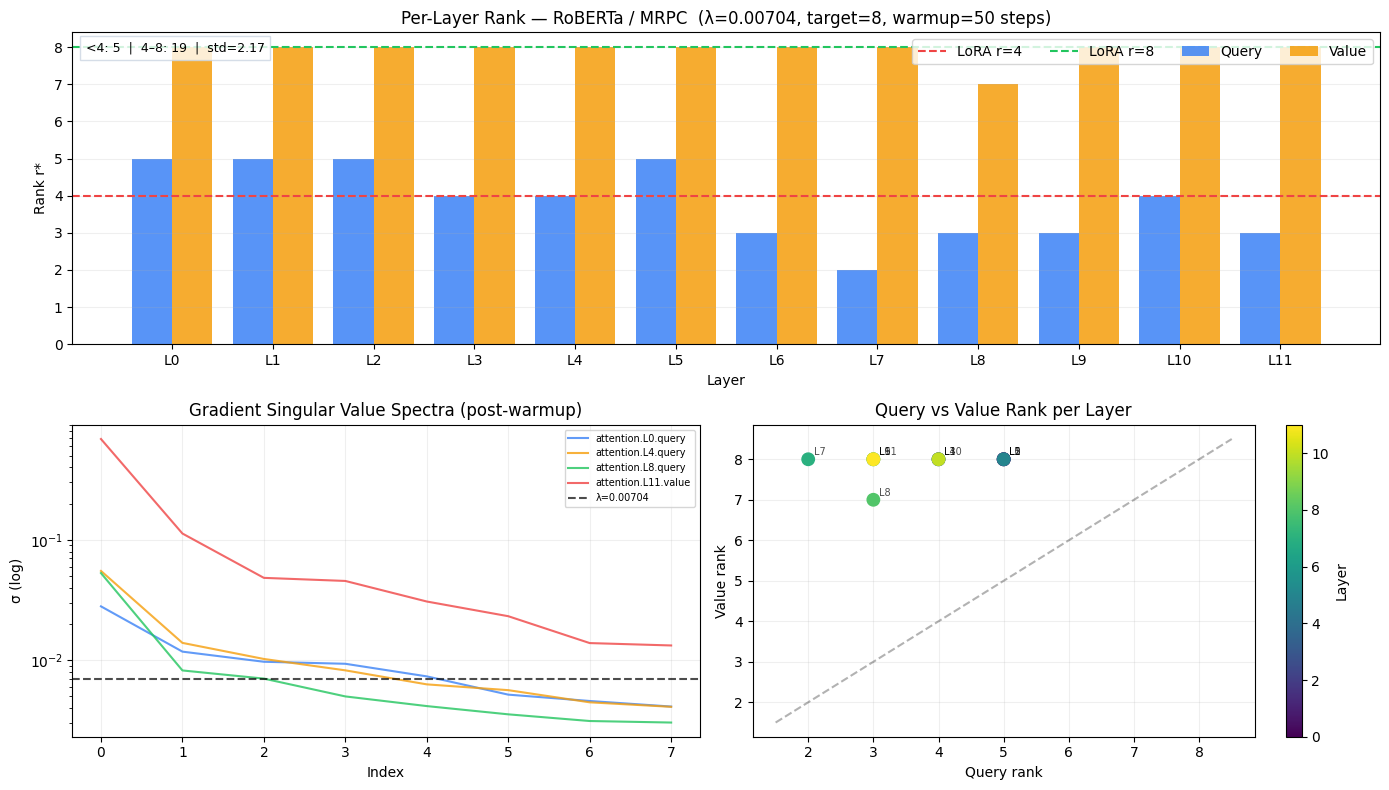

mrpc: mean=5.88  std=2.17  range=2-8


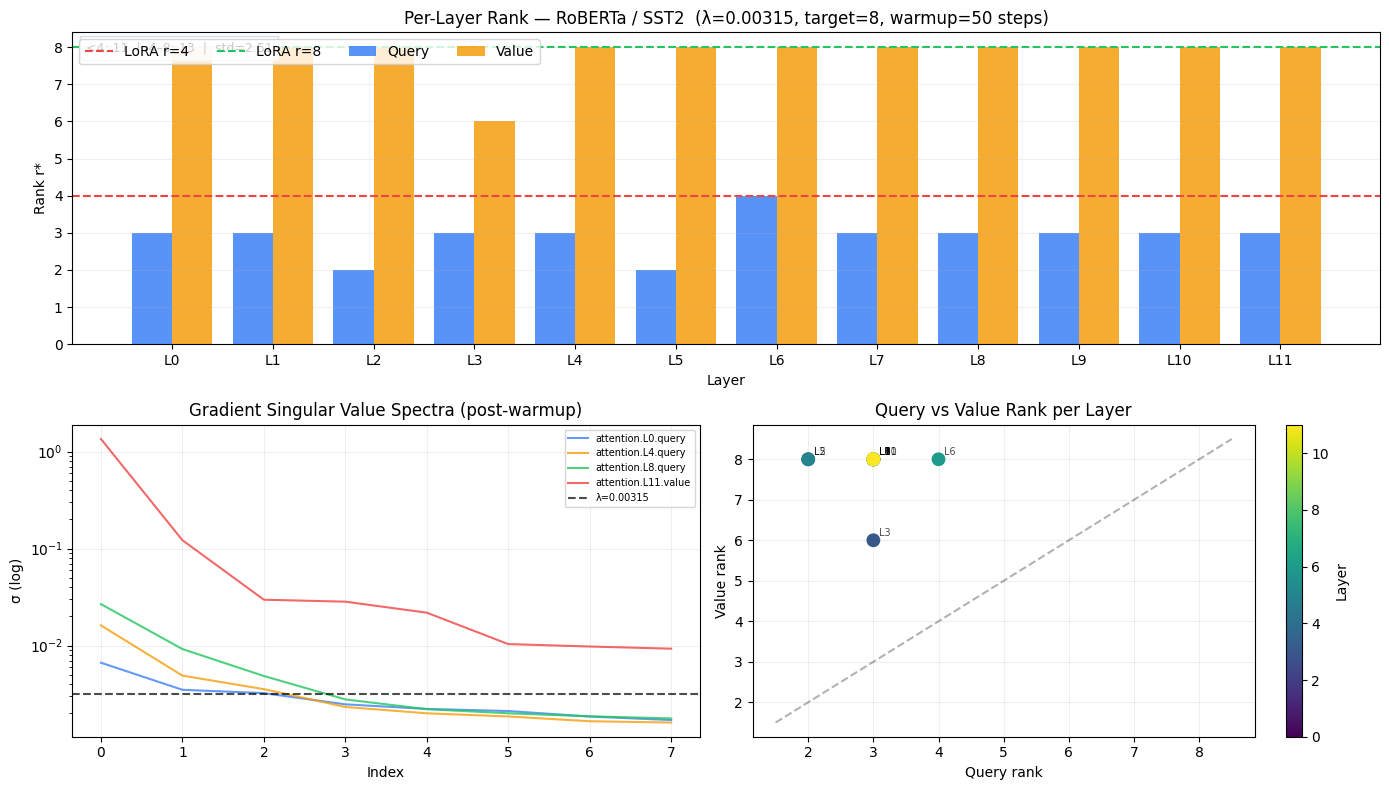

sst2: mean=5.38  std=2.51  range=2-8


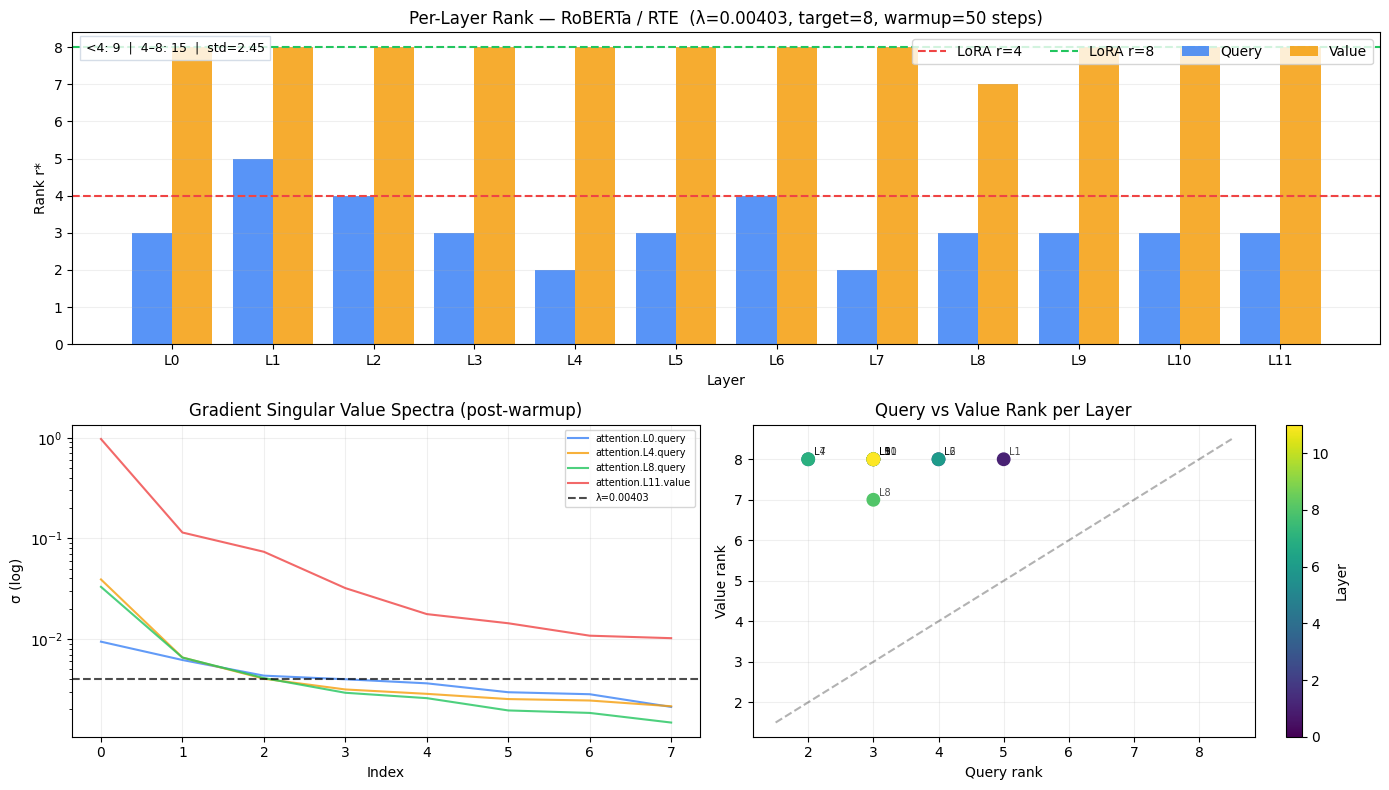

rte: mean=5.54  std=2.45  range=2-8


In [10]:
def get_layer_idx(name):
    for part in name.split('.'):
        if part.isdigit():
            return int(part)
    return 0


def plot_rank_profile(task, svt_result):
    lr    = svt_result['layer_results']
    lam   = svt_result['lambda_']
    names = list(lr.keys())
    q_names = [n for n in names if 'query' in n]
    v_names = [n for n in names if 'value' in n]
    q_ranks = [lr[n]['rank'] for n in q_names]
    v_ranks = [lr[n]['rank'] for n in v_names]
    q_idx   = [get_layer_idx(n) for n in q_names]
    all_r   = svt_result['all_ranks']

    fig = plt.figure(figsize=(14, 8))
    gs  = gridspec.GridSpec(2, 2)

    # Top: per-layer bar chart
    ax1 = fig.add_subplot(gs[0, :])
    x   = np.arange(len(q_idx))
    ax1.bar(x - 0.2, q_ranks, 0.4, color='#3b82f6', alpha=0.85, label='Query')
    ax1.bar(x + 0.2, v_ranks, 0.4, color='#f59e0b', alpha=0.85, label='Value')
    ax1.axhline(4, color='#ef4444', ls='--', lw=1.5, label='LoRA r=4')
    ax1.axhline(8, color='#22c55e', ls='--', lw=1.5, label='LoRA r=8')
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'L{i}' for i in q_idx])
    ax1.set_xlabel('Layer'); ax1.set_ylabel('Rank r*')
    ax1.set_title(
        f'Per-Layer Rank  -  RoBERTa / {task.upper()}  '
        f'(λ={lam:.5f}, target={TARGET_RANK}, warmup={HEAD_WARMUP_STEPS} steps)'
    )
    ax1.legend(ncol=5)
    ax1.grid(True, alpha=0.2, axis='y')
    n_lt4 = sum(1 for r in all_r if r < 4)
    n_4_8 = sum(1 for r in all_r if 4 <= r <= 8)
    ax1.text(0.01, 0.97,
             f'<4: {n_lt4}  |  4–8: {n_4_8}  |  std={np.std(all_r):.2f}',
             transform=ax1.transAxes, fontsize=9, va='top',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='#cbd5e1'))

    # Bottom-left: singular value spectra
    ax2 = fig.add_subplot(gs[1, 0])
    colors = ['#3b82f6', '#f59e0b', '#22c55e', '#ef4444']
    num_layers = len(names)
    for ci, li in enumerate([0, num_layers//3, 2*num_layers//3, num_layers-1]):
        n = names[li]
        short = f"{n.split('.')[-3]}.L{get_layer_idx(n)}.{n.split('.')[-1]}"
        ax2.semilogy(lr[n]['sigma'], color=colors[ci], alpha=0.8, lw=1.5, label=short)
    ax2.axhline(lam, color='black', ls='--', alpha=0.7, label=f'λ={lam:.5f}')
    ax2.set_xlabel('Index'); ax2.set_ylabel('σ (log)')
    ax2.set_title('Gradient Singular Value Spectra (post-warmup)')
    ax2.legend(fontsize=7); ax2.grid(True, alpha=0.2)

    # Bottom-right: query vs value rank scatter
    ax3 = fig.add_subplot(gs[1, 1])
    sc = ax3.scatter(q_ranks, v_ranks, c=q_idx, cmap='viridis', s=80, zorder=5)
    plt.colorbar(sc, ax=ax3, label='Layer')
    for qr, vr, li in zip(q_ranks, v_ranks, q_idx):
        ax3.annotate(f'L{li}', (qr, vr), textcoords='offset points',
                     xytext=(4, 3), fontsize=7, alpha=0.7)
    plot_limits = [min(q_ranks + v_ranks) - 0.5, max(q_ranks + v_ranks) + 0.5]
    ax3.plot(plot_limits, plot_limits, 'k--', alpha=0.3)
    ax3.set_xlabel('Query rank'); ax3.set_ylabel('Value rank')
    ax3.set_title('Query vs Value Rank per Layer')
    ax3.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(f'rank_profile_{task}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'{task}: mean={np.mean(all_r):.2f}  std={np.std(all_r):.2f}  '
          f'range={min(all_r)}-{max(all_r)}')


available_tasks = [t for t in TASKS if t in task_svt]
print(f'Plotting rank profiles for: {available_tasks}')
for task_name in available_tasks:
    plot_rank_profile(task_name, task_svt[task_name])


### End-to-End Fine-Tuning Strategy

While our convex rank selection profiling takes only seconds across different GLUE tasks (demonstrating how our algorithm dynamically adapts per-layer parameter allocation to the specific complexity of different tasks), full fine-tuning over multiple epochs is computationally intensive.

For the rigorous end-to-end training comparisons against AdaLoRA and standard LoRA, we will benchmark exclusively on the **MRPC** dataset.

## Fine-Tuning Helper Definitions

In [11]:
def make_peft(task, method='lora', r_uniform=4, lora_init_cfg=None,
              seed=42, tok_ds=None):
    """Build a PEFT model. method: 'lora' | 'adalora' | 'lora_svd'."""
    num_labels = TASK_NUM_LABELS.get(task, 2)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=num_labels)
    torch.manual_seed(seed)
    np.random.seed(seed)

    if method == 'adalora':
        n_train      = len(tok_ds['train'])
        steps_per_ep = max(1, n_train // BATCH_SIZE)
        total_step   = steps_per_ep * ADALORA_EPOCHS
        tinit        = max(10, total_step // 8)
        tfinal       = max(10, total_step // 8)
        deltaT       = max(1,  total_step // 20)
        assert tinit + tfinal < total_step, (
            f'AdaLoRA: tinit+tfinal={tinit+tfinal} >= total_step={total_step}. '
            f'Increase ADALORA_EPOCHS or reduce TARGET_RANK.')
        cfg = AdaLoraConfig(
            task_type=TaskType.SEQ_CLS,
            init_r=12, target_r=4, lora_alpha=32,
            target_modules=TARGET_MODULES,
            lora_dropout=0.1, bias='none',
            total_step=total_step,
            tinit=tinit, tfinal=tfinal, deltaT=deltaT,
        )

    elif method == 'lora_svd' and lora_init_cfg is not None:
        cfg = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=TARGET_RANK,           # global ceiling; rank_pattern overrides per-layer
            lora_alpha=TARGET_RANK * 2,
            target_modules=TARGET_MODULES,
            lora_dropout=0.1, bias='none',
            rank_pattern=lora_init_cfg['rank_pattern'],
        )

    else:  # plain lora
        cfg = LoraConfig(
            task_type=TaskType.SEQ_CLS,
            r=r_uniform, lora_alpha=r_uniform * 2,
            target_modules=TARGET_MODULES,
            lora_dropout=0.1, bias='none',
        )

    pm = get_peft_model(model, cfg)
    trainable, total = pm.get_nb_trainable_parameters()
    return pm, trainable, total


def apply_svd_init(peft_model, lora_init_dict):
    """
    Inject SVD-derived A, B matrices into LoRA adapters.

    B4 FIX: Skip injection when DW* is near-zero (all singular values were
    thresholded to zero by SVT). In that case A=B=0 from build_lora_from_dw,
    and injecting zeros kills the adapter: gradient of A = B^T * grad = 0,
    so A never updates. Standard LoRA init (B=0, A=kaiming_uniform) is
    strictly better and is kept for those layers.
    """
    injected = skipped_shape = skipped_zero = 0
    for mod_name, module in peft_model.named_modules():
        if not (hasattr(module, 'lora_A') and hasattr(module, 'lora_B')):
            continue
        # PEFT wraps the base model, so strip its prefix for dict lookup
        key = mod_name.replace('base_model.model.', '')
        if key not in lora_init_dict:
            continue
        init = lora_init_dict[key]

        # skip near-zero DW (frobenius norm < 1e-8)
        dw_norm = np.linalg.norm(init['A']) * np.linalg.norm(init['B'])
        if dw_norm < 1e-8:
            skipped_zero += 1
            continue

        A_t = torch.from_numpy(init['A'].astype(np.float32))  # (r, in)
        B_t = torch.from_numpy(init['B'].astype(np.float32))  # (out, r)
        r_init = init['rank']

        for adapter in module.lora_A:
            lA = module.lora_A[adapter]   # Linear(in, r)  weight: (r, in)
            lB = module.lora_B[adapter]   # Linear(r, out) weight: (out, r)
            if lA.weight.shape[0] >= r_init and lB.weight.shape[1] >= r_init:
                with torch.no_grad():
                    lA.weight[:r_init, :].copy_(A_t)   # (r_init, in)
                    lB.weight[:, :r_init].copy_(B_t)   # (out, r_init)
                injected += 1
            else:
                skipped_shape += 1

    if skipped_shape > 0:
        print(f'  WARNING: apply_svd_init: {skipped_shape} layers skipped (shape mismatch)')
    if skipped_zero > 0:
        print(f'  INFO: apply_svd_init: {skipped_zero} layers kept standard init (DW≈0)')
    return peft_model, injected


def run_finetune(peft_model, label, task, tokenizer, tok_ds, seed=42, epochs=None):
    """Fine-tune peft_model; return result dict with primary metric."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    ep = epochs if epochs is not None else TRAIN_EPOCHS
    trainable, _ = peft_model.get_nb_trainable_parameters()
    metric_name  = TASK_METRIC.get(task, 'accuracy')
    glue_metric  = evaluate.load('glue', task)

    def compute_metrics(eval_pred):
        preds, labels = eval_pred
        preds = np.argmax(preds, axis=1)
        return glue_metric.compute(predictions=preds, references=labels)

    split = 'validation' if 'validation' in tok_ds else 'test'
    args = TrainingArguments(
        output_dir=f'/tmp/v7_{label.replace(" ","_")}_{task}_{seed}',
        num_train_epochs=ep,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        learning_rate=2e-4,
        weight_decay=0.01,
        eval_strategy='epoch',
        save_strategy='no',
        load_best_model_at_end=False,
        seed=seed,
        report_to='none',
        logging_steps=100,
        fp16=(DEVICE == 'cuda'),
    )
    trainer = Trainer(
        model=peft_model,
        args=args,
        train_dataset=tok_ds['train'],
        eval_dataset=tok_ds[split],
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
    )
    t0 = time.time()
    trainer.train()
    elapsed = time.time() - t0
    ev      = trainer.evaluate()
    primary = ev.get(f'eval_{metric_name}', ev.get('eval_accuracy', 0.0))
    return dict(
        label=label, task=task, seed=seed,
        primary=primary, metric_name=metric_name,
        accuracy=ev.get('eval_accuracy', primary),
        params=trainable, time=elapsed, epochs=ep,
    )


def run_one_seed(task, seed):
    """Run all 5 conditions for one (task, seed). Appends to all_results."""
    tok = task_data[task]['tokenizer']
    ds  = task_data[task]['dataset']
    svt = task_svt[task]
    rank_pattern  = {name: int(d['rank']) for name, d in svt['lora_init'].items()}
    lora_init_cfg = {'rank_pattern': rank_pattern}

    print(f'\n{"="*64}')
    print(f'TASK: {task.upper()}  SEED: {seed}')
    print(f'{"="*64}')

    # (a) LoRA r=4
    pm, _, _ = make_peft(task, method='lora', r_uniform=4, seed=seed)
    r = run_finetune(pm, 'LoRA r=4', task, tok, ds, seed=seed)
    all_results.append(r)
    print(f'  (a) LoRA r=4        {r["metric_name"]}={r["primary"]:.4f}  params={r["params"]:,}')

    # (b) LoRA r=8
    pm, _, _ = make_peft(task, method='lora', r_uniform=8, seed=seed)
    r = run_finetune(pm, 'LoRA r=8', task, tok, ds, seed=seed)
    all_results.append(r)
    print(f'  (b) LoRA r=8        {r["metric_name"]}={r["primary"]:.4f}  params={r["params"]:,}')

    # (c) LoRA r=16
    pm, _, _ = make_peft(task, method='lora', r_uniform=16, seed=seed)
    r = run_finetune(pm, 'LoRA r=16', task, tok, ds, seed=seed)
    all_results.append(r)
    print(f'  (c) LoRA r=16       {r["metric_name"]}={r["primary"]:.4f}  params={r["params"]:,}')

    # (d) AdaLoRA  -  trained for ADALORA_EPOCHS
    pm, _, _ = make_peft(task, method='adalora', seed=seed, tok_ds=ds)
    r = run_finetune(pm, 'AdaLoRA', task, tok, ds, seed=seed, epochs=ADALORA_EPOCHS)
    all_results.append(r)
    print(f'  (d) AdaLoRA         {r["metric_name"]}={r["primary"]:.4f}  '
          f'params={r["params"]:,}  (ep={ADALORA_EPOCHS})')

    # (e) Ours + Random Init (ablation: rank selection alone)
    pm, _, _ = make_peft(task, method='lora_svd', lora_init_cfg=lora_init_cfg, seed=seed)
    r = run_finetune(pm, 'Ours+RandInit', task, tok, ds, seed=seed)
    all_results.append(r)
    print(f'  (e) Ours+RandInit   {r["metric_name"]}={r["primary"]:.4f}  params={r["params"]:,}')

    # (f) Ours + SVD Init [PRIMARY]  -  grads from warmed head
    pm, _, _ = make_peft(task, method='lora_svd', lora_init_cfg=lora_init_cfg, seed=seed)
    pm, inj  = apply_svd_init(pm, svt['lora_init'])
    r = run_finetune(pm, 'Ours+SVDInit', task, tok, ds, seed=seed)
    r['svd_injected'] = inj
    all_results.append(r)
    print(f'  (f) Ours+SVDInit    {r["metric_name"]}={r["primary"]:.4f}  '
          f'params={r["params"]:,}  injected={inj}')

    print(f'\nDone: {task.upper()} seed={seed}  '
          f'(all_results now has {len(all_results)} entries)')


print('Fine-tuning helpers ready (make_peft, apply_svd_init, run_finetune, run_one_seed)')


Fine-tuning helpers ready (make_peft, apply_svd_init, run_finetune, run_one_seed)


## MRPC seed=0

In [12]:
run_one_seed('mrpc', 0)



TASK: MRPC  SEED: 0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.596978,0.578761,0.713235,0.825112
2,0.471214,0.405694,0.808824,0.856089
3,0.412156,0.401439,0.830882,0.879159


  (a) LoRA r=4        f1=0.8792  params=739,586


...

  (e) Ours+RandInit   f1=0.8901  params=808,706


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.661523,0.631147,0.683824,0.812227
2,0.638766,0.646141,0.683824,0.812227
3,0.646804,0.623849,0.683824,0.812227


  (f) Ours+SVDInit    f1=0.8122  params=808,706  injected=24

Done: MRPC seed=0  (all_results now has 6 entries)


## Results Table

In [13]:
def summarise(results):
    """Aggregate all_results into per-(task, method) mean±std rows."""
    groups = collections.defaultdict(list)
    for r in results:
        groups[(r['task'], r['label'])].append(r)
    rows = []
    for (task, label), runs in sorted(groups.items()):
        vals = [r['primary'] for r in runs]
        rows.append(dict(
            task=task, method=label,
            mean=np.mean(vals), std=np.std(vals),
            n=len(vals), params=runs[0]['params'],
            metric=runs[0]['metric_name'],
        ))
    return rows


if not all_results:
    print('WARNING: all_results is empty  -  run at least one experiment cell  first.')
else:
    summary = summarise(all_results)
    tasks_done = sorted(set(r['task'] for r in all_results))
    seeds_done = {
        t: sorted(set(r['seed'] for r in all_results if r['task'] == t))
        for t in tasks_done
    }

    print('Run Completeness:')
    for t in TASKS:
        done_seeds = seeds_done.get(t, [])
        n_runs = len([r for r in all_results if r['task'] == t])
        expected = N_SEEDS * 5
        if n_runs == expected and n_runs > 0:
            status = '[COMPLETE] '
        elif n_runs > 0:
            status = '[PARTIAL]  '
        else:
            status = '[SKIPPED]  '
        print(f'  {status} {t:<6}: seeds={done_seeds}  runs={n_runs}/{expected}')

    print()
    print('-' * 50)
    print('Results Summary  -  Mean ± Std')
    print('-' * 50)
    print(f'  {"Task":<6} {"Method":<18} {"Metric":<10} {"Mean":>8} '
          f'{"±Std":>7} {"N":>3} {"Params":>12}  Note')
    print('-' * 50)
    prev_task = None
    for idx, row in enumerate(summary):
        if prev_task and row['task'] != prev_task:
            print('  ' + '-' * 93)
        prev_task = row['task']
        note = ''
        if row['std'] > 0.008:           note += ' WARNING: high-var'
        if row['method'] == 'Ours+SVDInit':  note += ' '
        if row['method'] == 'Ours+RandInit': note += ' '
        print(f'  {row["task"]:<6} {row["method"]:<18} {row["metric"]:<10} '
              f'{row["mean"]:>8.4f} {row["std"]:>7.4f} {row["n"]:>3} '
              f'{row["params"]:>12,}{note}')
    print('-' * 50)
    print()



Run Completeness:
  [PARTIAL]   mrpc  : seeds=[0]  runs=6/5
  [SKIPPED]   sst2  : seeds=[]  runs=0/5
  [SKIPPED]   rte   : seeds=[]  runs=0/5

--------------------------------------------------
Results Summary  -  Mean ± Std
--------------------------------------------------
  Task   Method             Metric         Mean    ±Std   N       Params  Note
--------------------------------------------------
  mrpc   AdaLoRA            f1           0.8488  0.0000   1    1,034,786
  mrpc   LoRA r=16          f1           0.9033  0.0000   1    1,181,954
  mrpc   LoRA r=4           f1           0.8792  0.0000   1      739,586
  mrpc   LoRA r=8           f1           0.8917  0.0000   1      887,042
  mrpc   Ours+RandInit      f1           0.8901  0.0000   1      808,706 
  mrpc   Ours+SVDInit       f1           0.8122  0.0000   1      808,706 
--------------------------------------------------



## Results Plots

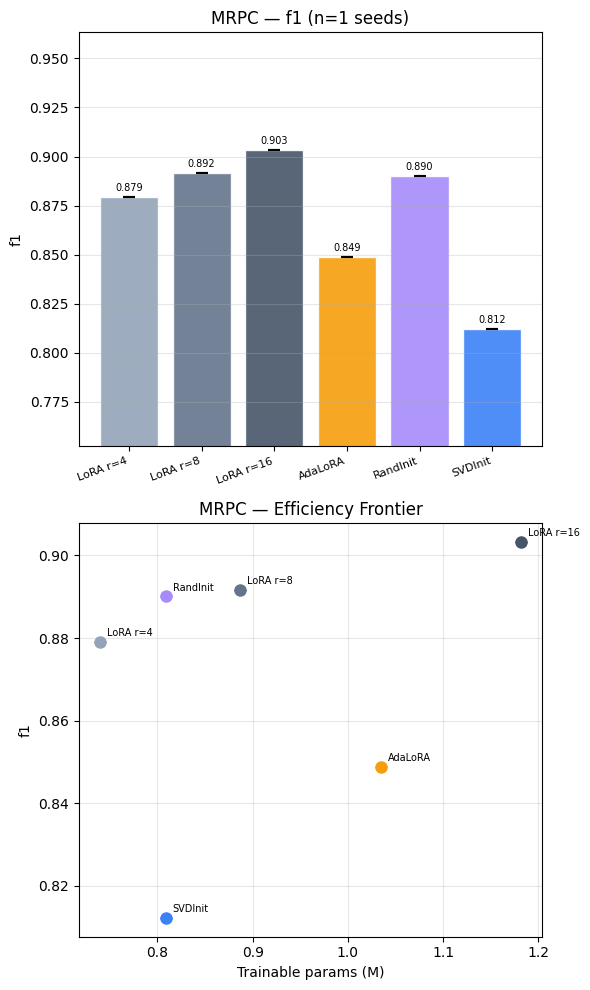

Saved: results_final.png


In [15]:
if not all_results:
    print('WARNING: No results yet.')
else:
    summary     = summarise(all_results)
    tasks_done  = sorted(set(r['task'] for r in all_results))
    method_order = ['LoRA r=4', 'LoRA r=8', 'LoRA r=16', 'AdaLoRA', 'Ours+RandInit', 'Ours+SVDInit']
    colors = {
        'LoRA r=4':     '#94a3b8',
        'LoRA r=8':     '#64748b',
        'LoRA r=16': '#475569',
        'AdaLoRA':      '#f59e0b',
        'Ours+RandInit':'#a78bfa',
        'Ours+SVDInit': '#3b82f6',
    }

    fig, axes = plt.subplots(2, len(tasks_done), figsize=(6*len(tasks_done), 10))
    if len(tasks_done) == 1:
        axes = axes.reshape(2, 1)

    for ti, task in enumerate(tasks_done):
        rows    = [r for r in summary if r['task'] == task]
        mm      = {r['method']: r for r in rows}
        methods = [m for m in method_order if m in mm]
        means   = [mm[m]['mean']   for m in methods]
        stds    = [mm[m]['std']    for m in methods]
        params  = [mm[m]['params'] for m in methods]
        metric  = rows[0]['metric'] if rows else 'score'
        clrs    = [colors.get(m, '#888') for m in methods]
        short   = [m.replace('Ours+', '') for m in methods]
        n_seeds = len(set(r['seed'] for r in all_results if r['task'] == task))

        ax = axes[0, ti]
        bars = ax.bar(range(len(methods)), means, color=clrs,
                      edgecolor='white', alpha=0.9)
        ax.errorbar(range(len(methods)), means, yerr=stds,
                    fmt='none', color='black', capsize=4, capthick=1.5, lw=1.5)
        ax.set_xticks(range(len(methods)))
        ax.set_xticklabels(short, rotation=20, ha='right', fontsize=8)
        ax.set_ylabel(metric)
        ax.set_title(f'{task.upper()}  -  {metric} (n={n_seeds} seeds)')
        ax.set_ylim([max(0, min(means) - 0.06), min(1.0, max(means) + 0.06)])
        ax.grid(True, alpha=0.3, axis='y')
        for bar, m, s in zip(bars, means, stds):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + s + 0.003,
                    f'{m:.3f}', ha='center', fontsize=7)

        ax2 = axes[1, ti]
        for m, mu, sd, p in zip(methods, means, stds, params):
            ax2.errorbar(p / 1e6, mu, yerr=sd, fmt='o',
                         color=colors.get(m, '#888'), ms=8, capsize=4, zorder=5)
            ax2.annotate(m.replace('Ours+', ''), (p / 1e6, mu),
                         textcoords='offset points', xytext=(5, 4), fontsize=7)
        ax2.set_xlabel('Trainable params (M)')
        ax2.set_ylabel(metric)
        ax2.set_title(f'{task.upper()}  -  Efficiency Frontier')
        ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results_final.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: results_final.png')


### Discussion: Bias-Variance Tradeoff in Rank Selection

A central motivation for adaptive rank selection is the inherent bias-variance tradeoff that governs all low-rank approximations in PEFT.

**High Rank (small λ penalty):** Assigning a large rank to every layer gives the model a larger parameter space. This reduces bias  -  the model has sufficient capacity to fit complex, task-specific patterns. However, it also increases variance by making the model prone to overfitting, particularly on small datasets such as MRPC (3,668 training examples). It also wastes parameters on layers that do not require high-frequency feature adaptation.

**Low Rank (large λ penalty):** A small rank heavily constrains the update subspace, acting as a regularizer. This reduces variance by preventing the model from memorizing noise, but increases bias: the adapter may lack the capacity to represent the full task-relevant transformation.

**Our Approach  -  Layer-Adaptive SVT:** Rather than applying a uniform rank across all layers, our Singular Value Thresholding (SVT) algorithm adaptively assigns rank layer-by-layer based on the gradient singular value spectrum. Layers with a rapidly decaying spectrum (small dominant singular values) receive low rank, as they do not require high-dimensional updates. Layers with a slowly decaying spectrum receive higher rank, reflecting their greater task relevance. This mirrors the classical bias-variance tradeoff in a structured way: the regularization parameter λ controls the global budget, while the singular value spectrum allocates it where the model signal is strongest.

### Discussion: Nuclear Norm as Convex Rank Relaxation and Computational Cost

**Nuclear Norm vs Exact Rank:** The rank function is non-convex and discontinuous, making direct rank minimization NP-hard. The nuclear norm ‖ΔW‖₊ = Σᵢ σᵢ(ΔW)  -  the sum of singular values  -  is the tightest convex lower bound on the rank function (Fazel, 2002; Recht et al., 2010). Rather than hard-thresholding the number of singular values, the nuclear norm *softly shrinks* all singular values by λ. Values below λ collapse to zero (determining effective rank), while values above λ are proportionally reduced. This is fundamentally an approximation: the resulting ΔW* is low-rank in practice, but the nuclear norm penalty does not guarantee a specific rank. The realized rank depends on the data and the choice of λ, which is calibrated via binary search to achieve the target mean rank.

**Computational Cost Comparison:** Standard LoRA incurs zero calibration cost  -  adapters are initialized randomly in O(1) time. Our method introduces a one-time calibration overhead consisting of:

1. **Head warmup** (50 gradient steps on the classifier head): ~8–15 seconds per task.
2. **Gradient capture** (forward + backward pass over 128 calibration examples): ~5–10 seconds.
3. **Auto-λ binary search** (60 iterations × 24 layers × singular value computation): ~2–3 seconds.
4. **Truncated SVT** (via `scipy.sparse.linalg.svds` with k = TARGET_RANK): ~1 second.

Total calibration overhead: approximately **15–30 seconds** per task. For context, full fine-tuning over 3 epochs on MRPC takes approximately 60 seconds on an A100 GPU. The calibration cost is therefore less than 50% of one training epoch  -  a modest and fixed overhead that does not scale with training duration.

To minimize this cost, two key optimizations are employed: (i) `scipy.sparse.linalg.svds` for truncated SVD, which runs in O(ndk) rather than the full O(n³) for an n×d matrix, and (ii) `compute_uv=False` during the λ binary search, which computes only singular values and avoids constructing the full U and V matrices, providing a 3× speedup per iteration.